In [2]:
import torch, numpy as np
from botorch import fit_gpytorch_mll
from botorch.test_functions.multi_fidelity import AugmentedHartmann, AugmentedRosenbrock, AugmentedBranin
# , BoreholeMultiFidelity, WingWeightMultiFidelity
from botorch.models.cost import AffineFidelityCostModel
from botorch.acquisition.cost_aware import InverseCostWeightedUtility
from botorch.acquisition import PosteriorMean
from botorch.acquisition.knowledge_gradient import qMultiFidelityKnowledgeGradient
from botorch.acquisition.fixed_feature import FixedFeatureAcquisitionFunction
from botorch.models.gp_regression_fidelity import SingleTaskMultiFidelityGP
from botorch.models.transforms.outcome import Standardize
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood
from botorch.optim.optimize import optimize_acqf_mixed
from botorch.optim.optimize import optimize_acqf
from botorch.acquisition.utils import project_to_target_fidelity
from botorch.acquisition.max_value_entropy_search import qMultiFidelityMaxValueEntropy
from botorch.models.deterministic import GenericDeterministicModel

import os
import torch
import warnings
warnings.filterwarnings('ignore')

tkwargs = {
    "dtype": torch.double,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}
SMOKE_TEST = os.environ.get("SMOKE_TEST")
tkwargs = {"dtype": torch.double, "device": "cpu"}
device = torch.device("cpu")
dtype = torch.double


In [3]:

def get_mfmes(model, candidate_set, project, cost_aware_utility):

    return qMultiFidelityMaxValueEntropy(
        model=model,
        candidate_set=candidate_set,   # discretized candidate points
        cost_aware_utility=cost_aware_utility,
        project=project,
        maximize=True,
    )

In [4]:
torch.set_printoptions(precision=3, sci_mode=False)

NUM_RESTARTS = 12 if not SMOKE_TEST else 2
RAW_SAMPLES = 256 if not SMOKE_TEST else 4
BATCH_SIZE = 1

def optimize_mfmes_and_get_observation(f, candidate_set, mfmes_acqf, bounds,cost_model):
    """Optimizes MFKG and returns a new candidate, observation, and cost."""

    # generate new candidates
    candidates, _ = optimize_acqf(
        acq_function=mfmes_acqf,
        bounds=bounds,
        q=BATCH_SIZE,
        num_restarts=NUM_RESTARTS,
        raw_samples=RAW_SAMPLES,
        options={"batch_limit": 5, "maxiter": 200}
    )

    return candidates

In [5]:
# Continuous fidelity initial design
def draw_initial(
    f,
    n: int = 20,
    flag_two_fid: bool = False,
):
    """
    Generate an initial design with *continuous* fidelities.

    flag_two_fid = False  -> layout [x_part , s]
    flag_two_fid = True   -> layout [x_part , s1 , s2]

    Assumes:
      - f.dim is the total input dimension
      - The last 1 (or 2) dimensions of f.bounds are fidelity dims.
    """

    # how many x-dimensions (everything before the fidelity dims)
    dim_x = f.dim - (2 if flag_two_fid else 1)

    bounds = f.bounds.clone().to(dtype=dtype, device=device)
    # # For any problem where last 2 dims are fidelities in [0,1]
    # if flag_two_fid:
    #     bounds[0, -2:] = 0.0
    #     bounds[1, -2:] = 1.0
    # else:
    #     bounds[0, -1] = 0.0
    #     bounds[1, -1] = 1.0

    # ------------------------------------------------------------------#
    # 1) sample design variables x in their physical bounds
    # ------------------------------------------------------------------#
    low_x  = bounds[0, :dim_x]        # (dim_x,)
    high_x = bounds[1, :dim_x]        # (dim_x,)

    u_x    = torch.rand(n, dim_x, dtype=torch.double, device=device)
    x_part = low_x + (high_x - low_x) * u_x      # (n , dim_x)

    # ------------------------------------------------------------------#
    # 2) sample continuous fidelity variable(s) from their bounds
    # ------------------------------------------------------------------#
    n_fid   = 2 if flag_two_fid else 1
    low_s   = bounds[0, dim_x: dim_x + n_fid]    # (n_fid,)
    high_s  = bounds[1, dim_x: dim_x + n_fid]    # (n_fid,)
    u_s     = torch.rand(n, n_fid, dtype=torch.double, device=device)
    s_part  = low_s + (high_s - low_s) * u_s     # (n, n_fid), broadcast

    # ------------------------------------------------------------------#
    # 2b) Force a proportion of initial points to be at highest fidelity
    # ------------------------------------------------------------------#
    # Choose how many high-fidelity points you want in the initial design.
    # Here: 20% of n (at least 1), change 0.20 to whatever proportion you want.
    hf_prop = 0.20
    n_hf = max(1, int(round(hf_prop * n)))

    # Randomly pick which rows become high-fidelity
    idx = torch.randperm(n, device=device)[:n_hf]

    # Set all fidelity dims to 1.0 for those rows
    s_part[idx, :] = 1.0
    
    # ------------------------------------------------------------------#
    # 3) build the full X matrix
    # ------------------------------------------------------------------#
    X0 = torch.cat([x_part, s_part], dim=-1)      # (n , dim_x + n_fid)

    Y0 = f(X0).unsqueeze(-1)
    return X0, Y0


In [6]:
def build_mf_model(train_x, train_y, data_fidelities):
    """
    train_x:  (n, d)
    train_y:  (n, 1)
    data_fidelities: list[int] or single int
    """
    if isinstance(data_fidelities, int):
        data_fidelities = [data_fidelities]

    model = SingleTaskMultiFidelityGP(
        train_X=train_x,
        train_Y=train_y,
        linear_truncated=True,
        outcome_transform=Standardize(m=1),
        data_fidelities=data_fidelities,
    )

    # # Put a *floor* on the noise so it cannot collapse to ~0
    # noise_constraint = GreaterThan(1e-2)
    # model.likelihood.noise_covar.register_constraint("raw_noise", noise_constraint)
    # # Initialize noise a bit above the floor
    # model.likelihood.noise = 1e-2

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    return model, mll

In [ ]:
# ------------------------------------------------------------------
# Cost‑aware MF‑MES BO loop – single run
# ------------------------------------------------------------------
import torch, math, matplotlib.pyplot as plt
import torch, math, warnings, time, pandas as pd
import matplotlib.pyplot as plt
import botorch
from typing import Sequence
from __future__ import annotations
from typing import Callable
from botorch.acquisition.fixed_feature import FixedFeatureAcquisitionFunction
from botorch.acquisition import PosteriorMean
from botorch.models.gp_regression_fidelity import SingleTaskMultiFidelityGP
from botorch.models.transforms.outcome import Standardize
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch import fit_gpytorch_mll
from botorch.optim.optimize import optimize_acqf, optimize_acqf_mixed
from botorch.settings import debug
from botorch.exceptions import ModelFittingError
# ------------------------------------------------------------------
# Main runner – single MF‑KG run, cost‑aware
# ------------------------------------------------------------------

def run_cost_aware_mfmes_bo_once(
    f: Callable,
    T: int = 30,
    init_n: int = 16,
    s_hi: float = 1.0,          # high fidelity value, used for all fidelity dims
    cost_dict: dict | None = None,
    seed: int | None = None,
    per_run_plots: bool = True,
    flag_two_fid: bool = False,
):
    if seed is not None:
        torch.manual_seed(int(seed))

    # ------------------------------------------------------------------
    # 1) Generate initial design  (continuous fidelities)
    # ------------------------------------------------------------------
    # Assumes draw_initial now samples continuous fidelities from bounds
    # and uses last 1 or 2 dims of f.bounds as fidelity dims.
    train_x, train_y = draw_initial(f, init_n, flag_two_fid=flag_two_fid)
    print(f"X values are : {train_x.tolist()}")
    print(f"Y values are : {train_y.squeeze(-1).tolist()}")    

    # ------------------------------------------------------------------
    # 2) Dimensions & bounds
    # ------------------------------------------------------------------
    if flag_two_fid:
        # last TWO dims are fidelities
        dim_x   = f.dim - 2               # design dimensions
        d_total = f.dim
        fid_dims = [f.dim - 2, f.dim - 1] # <-- BOTH fidelity dims
    else:
        # last ONE dim is fidelity
        dim_x   = f.dim - 1
        d_total = f.dim
        fid_dims = [f.dim - 1]            # <-- single fidelity dim

    bounds = f.bounds.clone().detach().to(**tkwargs)
    # # For any problem where last 2 dims are fidelities in [0,1]
    # if flag_two_fid:
    #     bounds[0, -2:] = 0.0
    #     bounds[1, -2:] = 1.0
    # else:
    #     bounds[0, -1] = 0.0
    #     bounds[1, -1] = 1.0

    # ------------------------------------------------------------------
    # 3) Cost model & projection to high fidelity
    # ------------------------------------------------------------------
    if len(fid_dims) == 1:
        w = (cost_dict or {}).get("w", 1.0)
        fixed_cost = (cost_dict or {}).get("fixed_cost", 0.0)
        fidelity_weights = {fid_dims[0]: w}
    else:  # two fidelity dims
        fixed_cost = (cost_dict or {}).get("fixed_cost", 0.0)
        w1 = (cost_dict or {}).get("w1", 1.0)
        w2 = (cost_dict or {}).get("w2", 1.0)
        fidelity_weights = {fid_dims[0]: w1, fid_dims[1]: w2}

    cost_model = AffineFidelityCostModel(
        fidelity_weights=fidelity_weights,
        fixed_cost=fixed_cost,
    )

    cost_aware_utility = InverseCostWeightedUtility(cost_model=cost_model)

    # high fidelity = s_hi in *all* fidelity dimensions
    target_fidelities = {d: s_hi for d in fid_dims}

    def project(X: torch.Tensor) -> torch.Tensor:
        # Projects ANY X to high fidelity in all fidelity dims
        return project_to_target_fidelity(X=X, target_fidelities=target_fidelities)

    # ------------------------------------------------------------------
    # 4) Initial GP + recommendation
    # ------------------------------------------------------------------

    model, mll = build_mf_model(train_x, train_y, data_fidelities=fid_dims)
    fit_gpytorch_mll(mll)
    # model = fit_mf_gp_safe(train_x, train_y, fid_dims=fid_dims)

    total_cost = 0.0
    prev_best = float("-inf")
    current_best = prev_best
    t = 0
    iter_idx, cum_cost_hist, best_hi_hist = [], [], []

    # Discrete candidate set for MF-mes over the full continuous domain
    candidate_set = torch.rand(3000, d_total, **tkwargs)
    candidate_set = bounds[0] + (bounds[1] - bounds[0]) * candidate_set

    # ------------------------------------------------------------------
    # 5) BO loop (continuous fidelities)
    # ------------------------------------------------------------------
    iters_since_hf = 0  # number of consecutive BO iters without an HF evaluation
    for t in range(T):

        # # -----------------------------------------------------------
        # # Every 5 iterations: ensure at least one evaluation at s_hi
        # # in the most recent 5 BO samples (new_x's).
        # # If none, force this iteration to evaluate at s_hi.
        # # -----------------------------------------------------------
        # # force_hf = ((t + 1) % 5 == 0) and (iters_since_hf >= 4)
        # hf_exploit = ((t + 1) % 5 == 0) and (iters_since_hf >= 4)
        # if (t + 1) % 5 == 0:
        #     # look at the last up-to-5 evaluated points so far
        #     last_k = min(5, train_x.shape[0])
        #     X_recent = train_x[-last_k:]

        #     tol_hf = 1.1e-2
        #     recent_hf_mask = torch.ones(X_recent.shape[0], dtype=torch.bool, device=train_x.device)
        #     for d in fid_dims:
        #         recent_hf_mask &= torch.isclose(
        #             X_recent[:, d],
        #             torch.as_tensor(s_hi, dtype=train_x.dtype, device=train_x.device),
        #             atol=tol_hf, rtol=0.0,
        #         )

        #     if not recent_hf_mask.any():
        #         hf_exploit = True


        # if hf_exploit:
        #     # -------------------------------------------------------
        #     # HF exploitation step: maximize model posterior mean at s = s_hi
        #     # -------------------------------------------------------
        #     pm = PosteriorMean(model)
        #     fixed_features = {d: float(s_hi) for d in fid_dims}

        #     # Optimize over full bounds; fixed-feature wrapper will clamp fidelity dims.
        #     new_x, _ = optimize_acqf(
        #         acq_function=pm,
        #         bounds=bounds,
        #         q=1,
        #         num_restarts=12,
        #         raw_samples=256,
        #         fixed_features=fixed_features,
        #         options={"batch_limit": 5, "maxiter": 200},
        #     )


        # else:
        mfmes_acqf = get_mfmes(
            model=model,
            candidate_set=candidate_set,
            project=project,
            cost_aware_utility=cost_aware_utility
        )

        # Continuous optimization over all dims (no fixed_features_list)
        new_x = optimize_mfmes_and_get_observation(
            f=f,
            candidate_set=candidate_set,
            mfmes_acqf=mfmes_acqf,
            bounds=bounds,
            cost_model=cost_model,
        )

        # # If we must sample high fidelity on this iteration, overwrite fidelity dim(s)
        # # if force_hf:
        # if hf_exploit:
        #     new_x = new_x.clone()
        #     for d in fid_dims:
        #         new_x[0, d] = torch.as_tensor(s_hi, dtype=new_x.dtype, device=new_x.device)
                
        # # Update HF counter
        # tol_hf = 1e-3
        # is_hf = True
        # for d in fid_dims:
        #     is_hf = is_hf and torch.isclose(
        #         new_x[0, d],
        #         torch.as_tensor(s_hi, dtype=new_x.dtype, device=new_x.device),
        #         atol=tol_hf, rtol=0.0,
        #     ).item()

        # iters_since_hf = 0 if is_hf else (iters_since_hf + 1)
        
        new_y = f(new_x).view(1, 1)
        cost_this_iter = cost_model(new_x).squeeze(-1).squeeze(-1).item()
        
        total_cost += cost_this_iter
        iter_idx.append(t + 1)
        cum_cost_hist.append(total_cost)

        # Append data
        train_x = torch.cat([train_x, new_x], dim=0)
        train_y = torch.cat([train_y, new_y], dim=0)

        # ---- Best high-fidelity value (all fidelity dims near s_hi) ----
        tol = 1.1e-2
        hf_mask = torch.ones(train_x.shape[0], dtype=torch.bool, device=train_x.device)
        for d in fid_dims:
            hf_mask &= train_x[:, d] >= (s_hi - tol)

        if hf_mask.any():
            prev_best = train_y[hf_mask].max().item()
        current_best = prev_best  # forward-filled
        best_hi_hist.append(current_best)

        # Re-fit model with the updated data
        model, mll = build_mf_model(train_x, train_y, data_fidelities=fid_dims)
        fit_gpytorch_mll(mll)
        # model = fit_mf_gp_safe(train_x, train_y, fid_dims=fid_dims)


        # Progress print
        if t % 1 == 0 or t == T - 1:
            s_vals = new_x[0, fid_dims].tolist()
            s_str = ", ".join(f"{sv:.3f}" for sv in s_vals)
            print(
                f"Iter {t + 1:02d} | s=[{s_str}] | y={new_y.item():.3f} "
                f"| cost={cost_this_iter:.3f} | cum_cost={total_cost:.3f} "
                f"| best_hf={current_best:.3f}"
            )
    
    # ------------------------------------------------------------------
    # 6) Plots
    # ------------------------------------------------------------------
    if per_run_plots:
        plt.figure()
        plt.plot(cum_cost_hist, best_hi_hist, linewidth=1)
        plt.xlabel("Cumulative cost")
        plt.ylabel(f"Best observed @ s≈{s_hi} in all fid dims")
        plt.title("Best high fidelity vs cumulative cost")
        plt.grid(True)
        plt.show()

    # ------------------------------------------------------------------
    # 7) Return summary
    # ------------------------------------------------------------------
    return {
        "cum_cost": cum_cost_hist,
        "best_hi": best_hi_hist,
    }


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tests import AugmentedBukin, AugmentedRastrigin, AugmentedAckley
from tests_pc import SuzukiMFEmulator

def run_single(f, seed: int, total_iters: int = 35):
    """Run a single BO experiment and return a DataFrame of its trajectory.

    Assumes:
      - Continuous fidelity variable(s).
      - run_cost_aware_mfkg_bo_once uses AffineFidelityCostModel, with cost_dict
        interpreted as:
          * one fidelity dim:  {"fixed_cost": c0, "w": w}
              cost(s) = c0 + w * s
          * two fidelity dims: {"fixed_cost": c0, "w1": w1, "w2": w2}
              cost(s1, s2) = c0 + w1 * s1 + w2 * s2
    """

    # -------------------------------------------------------
    # pick defaults based on the *type* of f
    #   (no more s_choices / probs – everything is continuous)
    # -------------------------------------------------------
    if isinstance(f, AugmentedHartmann):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False     # 1 fidelity dim (last column)
        s_hi        = 1.0        # high fidelity at s = 1

    elif isinstance(f, AugmentedBranin):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False
        s_hi        = 1.0

    elif isinstance(f, (AugmentedBukin, AugmentedRastrigin, AugmentedAckley)):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False
        s_hi        = 1.0

    # elif isinstance(f, AugmentedRosenbrock):
    #     cost_dict   = {"fixed_cost": 5.0, "w1": 1.0, "w2": 1.0}
    #     flag_two_fid = True      # 2 fidelity dims (last two columns)
    #     s_hi        = 1.0        # high fidelity at (1,1)

    elif isinstance(f, SuzukiMFEmulator):
        cost_dict    = {"fixed_cost": 5.0, "w": 1.0}  # cost increases with fidelity
        flag_two_fid = False
        s_hi         = 1.0



    else:
        raise ValueError(
            "Unknown function"
        )

    # -------------------------------------------------------
    # run the BO loop with those settings (continuous fidelity)
    # -------------------------------------------------------
    results = run_cost_aware_mfmes_bo_once(
        f=f,
        T=total_iters,
        init_n=32,
        s_hi=s_hi,
        cost_dict=cost_dict,
        seed=seed,
        per_run_plots=True,
        flag_two_fid=flag_two_fid,
    )

    df = pd.DataFrame({
        "iteration":       np.arange(1, len(results["cum_cost"]) + 1),
        "cumulative_cost": results["cum_cost"],
        "best_hi":         results["best_hi"],
    })
    return df



def aggregate_runs(dfs):
    """Stack per-run dataframes and compute mean & std."""
    merged = (
        pd.concat(
            {i: df.set_index("iteration") for i, df in enumerate(dfs)},
            names=["run", "iteration"],
        )
        .reset_index(level="run")
    )
    stats = (
        merged.groupby("iteration")
        .agg(["mean", "std"])  # adds a 2-level column index
    )
    # Flatten multi-index columns: e.g. ('cumulative_cost','mean') → 'cumulative_cost_mean'
    stats.columns = [f"{col}_{stat}" for col, stat in stats.columns]
    return stats.reset_index()

def plot_with_band(iterations, mean, std, ylabel, title):
    plt.figure()
    plt.plot(iterations, mean, lw=2, label="mean")
    plt.fill_between(iterations, mean - std, mean + std, alpha=0.25, label="±1 σ")
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

def plot_best_vs_cost(cost_mean, cost_std, best_mean, best_std,
                      title="Best observed vs. cumulative cost (mean ± 1 σ)",
                      optimum_val=None):
    """
    Scatter-line plot of mean best-observed value vs mean cumulative cost,
    with a shaded ±1 σ region around the best value.
    """
    # sort by cost so the line is monotone
    order = np.argsort(cost_mean)
    cost_mean, best_mean = cost_mean.iloc[order], best_mean.iloc[order]
    best_std            = best_std.iloc[order]

    plt.figure()
    plt.plot(cost_mean, best_mean, lw=2, label="mean trajectory")
    plt.fill_between(cost_mean,
                     best_mean - best_std,
                     best_mean + best_std,
                     alpha=0.25,
                     label="±1 σ (best)")
    if optimum_val is not None:
        plt.axhline(optimum_val, ls="--", label=f"True optimum = {optimum_val}")

    plt.xlabel("Cumulative cost (mean)")
    plt.ylabel("Best observed hi-fidelity value (mean)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()



=== Running bukin (iters=50) ===
X values are : [[-9.612311486351118, -2.214941074621244, 1.0], [-11.65262127928478, -2.7430736509476787, 0.37624417619297146], [-9.352436895124576, 2.4008180568909783, 0.8716425167731032], [-13.410282144820174, 1.2714129373692948, 0.8443882958944554], [-5.860866782237574, -1.9060372289995111, 0.3270444621387072], [-7.131593823791422, 1.251213762039642, 0.04260145689125805], [-10.784639302281825, 1.7602238257771248, 0.11536339288312047], [-6.855892559118153, -2.565816099205268, 0.8765465206844], [-5.899234765977461, -0.9245365032508088, 0.2860712633430066], [-11.195047173113075, 1.7063012645529092, 0.033144884543322206], [-11.212339231165487, -1.2047430872617764, 0.20340975110192405], [-13.825280399361963, 2.452928575148116, 1.0], [-12.417809776837608, 2.474729829450819, 0.37393265486673777], [-14.135111255883148, 1.6213071267661707, 1.0], [-8.291916486463531, 2.1798564420687256, 0.633730446757482], [-5.938946037629828, -2.1755080354999654, 0.9316761082

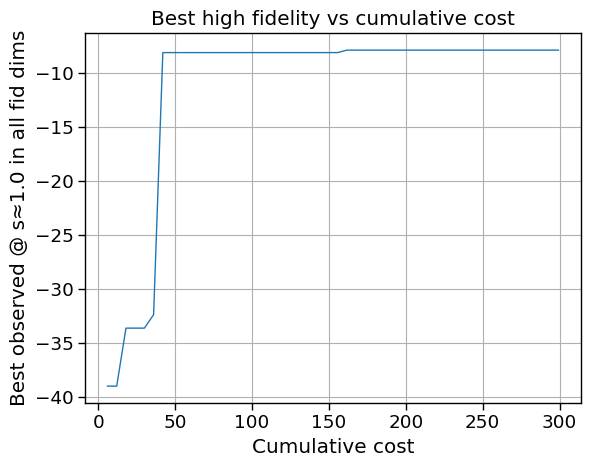

X values are : [[-5.51259665640557, 0.2979831770357335, 0.5778989074811894], [-8.932404896300799, -2.437336607145296, 0.2115062317363371], [-9.29638504541565, 2.7706249607745495, 0.377057529864983], [-12.333999393167783, -1.4390777211780568, 0.883913656475787], [-9.367518297330179, 0.194915249028214, 0.45298695811303225], [-11.250637905723437, 1.0836552514181577, 0.3398741961923747], [-5.660903628707015, 1.0944674696487624, 1.0], [-13.751951476257045, 0.15385712857920364, 0.0373721196279031], [-9.734687337230836, 2.051934750751017, 0.8548660355941547], [-13.354752714508212, -1.530521876815096, 0.29742992257439327], [-11.442209367784738, -0.42331922277694156, 1.0], [-10.466531488259822, 1.4110205318876723, 0.10065354959999051], [-14.909765430132726, -0.9964796449984132, 0.2162756087915343], [-7.887420081009484, -2.0881893710417723, 1.0], [-6.492797553548455, 1.1949071337282273, 0.914100162742853], [-13.466541123847875, 0.4454726258872128, 0.8781153651582062], [-10.754105207034002, 2.186

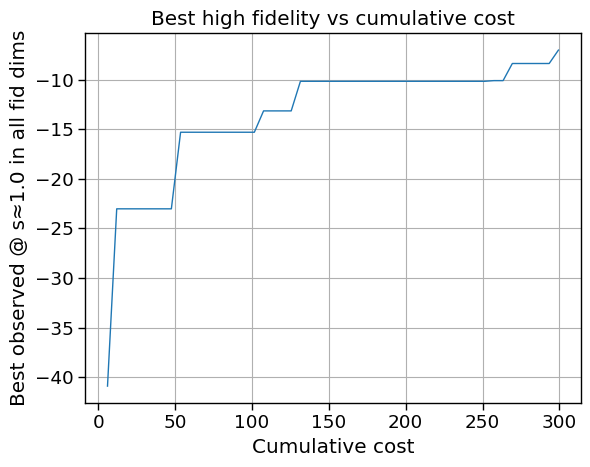

X values are : [[-14.418455140385703, -2.6225389954525347, 0.35387974120819565], [-13.76413927225591, -2.6845190138335377, 0.44158710288962544], [-9.73828103145238, -0.13929147727512214, 1.0], [-5.447642997508584, 2.5725154887445774, 0.8994208170256335], [-14.164566312471322, -2.2041559670778086, 0.6797180250341439], [-13.42946502489292, -0.7477978076969967, 0.1444427601821312], [-6.574802691685132, 2.223006250702185, 0.5572926496894439], [-11.224670447294406, 0.6746195339627477, 0.9697166888657457], [-14.11890215085429, 1.2070913516988044, 1.0], [-8.765969166457994, -0.37632601325608706, 0.06500730459327841], [-14.252651215262519, 1.1005813026399656, 0.6438373142919297], [-11.877613192770374, -1.1456473366603652, 0.006669421279685617], [-14.686598345725844, -2.7578011940402565, 0.5616610555457975], [-5.680912101450014, -2.0872450354646137, 0.6434349662308111], [-12.349550882516391, -2.217399044207373, 1.0], [-12.481447790586763, -1.5995508656523132, 0.2998241972730996], [-12.743349012

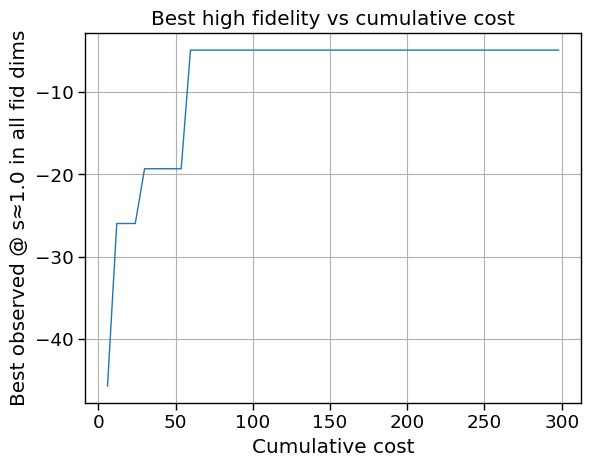

X values are : [[-13.154484709841334, 0.855331157306698, 1.0], [-14.56858323851646, 0.5525371233663194, 0.34785989921958416], [-9.180444567656298, 2.282790556321019, 1.0], [-13.909936659318394, -0.9945288609536851, 0.3836965685939472], [-7.835334923394295, 0.6681736589691272, 1.0], [-14.436830580762027, -1.5222264351836077, 0.02261922476731426], [-13.393503822069494, -1.7390519242868179, 0.1430289886197983], [-9.480728178740407, 1.5556697298995523, 0.9454086206957613], [-10.800790730599727, 0.32065815371886774, 0.713823261893377], [-6.991202484101807, 1.9880849978215274, 1.0], [-8.81393060699707, -2.188500273750847, 0.4121973567206698], [-14.705795420707947, 2.8043470781398723, 0.08810808766087164], [-7.218564581765914, -1.4363097431426837, 0.9138666908056479], [-9.52360235176693, 2.9861516410724054, 0.08076706313252702], [-11.84084224303399, 2.265865532821995, 0.8276142229481592], [-6.3062115839282775, -0.7716560893037778, 0.01867576564230522], [-6.935119709652797, 0.9328002470235122,

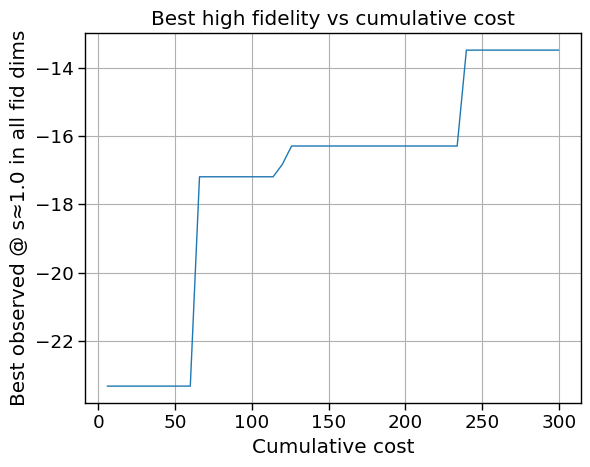

X values are : [[-10.006407126115148, -2.874690484328263, 0.4243421304607977], [-5.3944175265055705, -0.32024884403890486, 0.949912054673684], [-5.091930702115054, -0.3825606846517067, 0.9902633592812552], [-5.827909751274893, 0.5894439262906328, 0.9156834308532943], [-6.1461666795619525, 0.9177073794380259, 1.0], [-6.8602179194197905, 1.2094000894154133, 0.5786147140099096], [-9.993443868594106, 1.5965809496485024, 0.602197395563146], [-7.026834927503327, -1.8558938362748851, 0.10626062732050467], [-6.044825125706257, 0.6301648601787364, 1.0], [-12.793285567153596, 0.34164322552557014, 0.5520524080589795], [-5.49735447093353, 0.8143374477935343, 0.7445714560192194], [-6.59846900203131, -1.5511018841290172, 1.0], [-11.532958673254086, 2.4236068145516594, 1.0], [-13.009382480434997, -1.04149743347989, 0.2235382895735063], [-7.486238115953522, -2.2478014629838463, 0.047058564173168005], [-9.90608732390265, -0.36035758898342163, 0.5273068255250845], [-14.710406063946595, 0.320648110908561

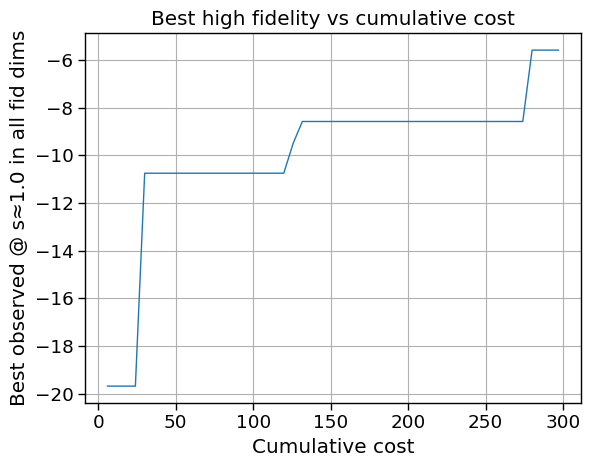

X values are : [[-5.962811701660028, 2.629975179728337, 0.5171576551020096], [-7.919885535194497, -2.399752121527282, 0.1946687813030733], [-6.242505119656673, -2.4185681864722977, 0.025835561652014505], [-9.6909916108356, 1.641657597001604, 0.6495384731735632], [-11.68134770746793, -2.750454383202073, 1.0], [-14.553684300720644, -2.107594106720681, 0.47626637745760425], [-12.575525524441343, -1.3376010993581358, 0.0633172151682374], [-8.07729921514402, -0.269001969258825, 0.9399196485590121], [-6.6672908936734725, 1.5702475759988843, 0.3619900787024427], [-6.627248718983797, -1.2173685788111324, 0.2839381850855991], [-10.493947482911889, 2.148085996697775, 0.4229415769570791], [-10.569259455167927, 1.442243597388435, 0.6020496821815903], [-6.991485660118231, -2.862365982847302, 0.08512799174200947], [-10.493781626871844, 2.7485912387594107, 1.0], [-8.865087749510375, 1.4520465551185993, 0.2851324232679626], [-6.887966143409702, 2.382282202030831, 0.5433475203777849], [-10.931816628451

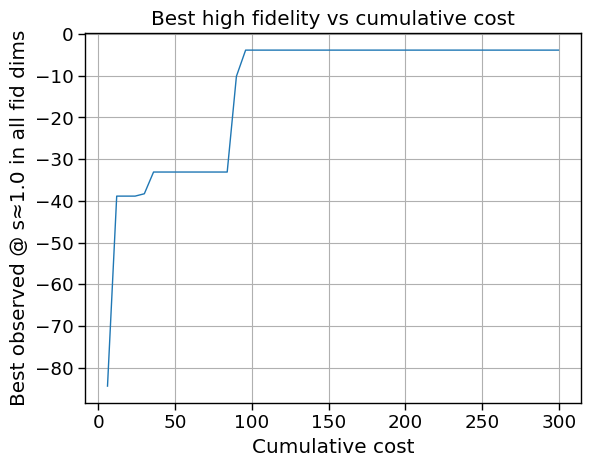

Saved aggregate stats → mf_mes_runs_cont_bukin.csv


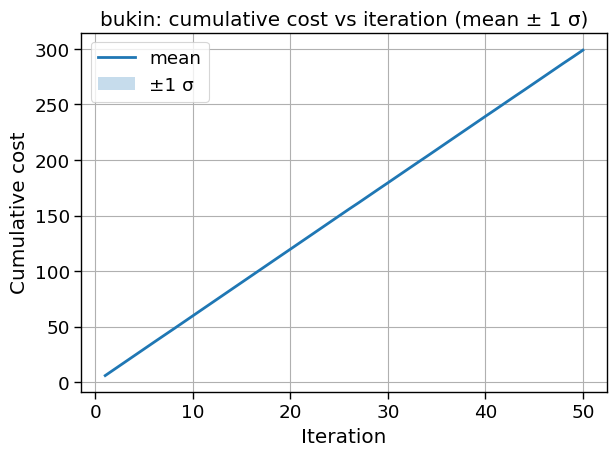

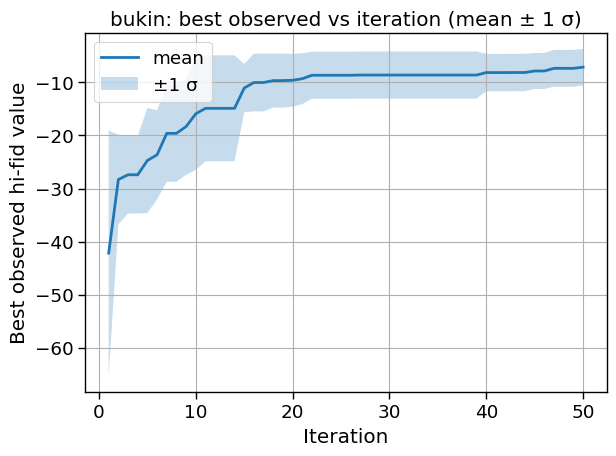

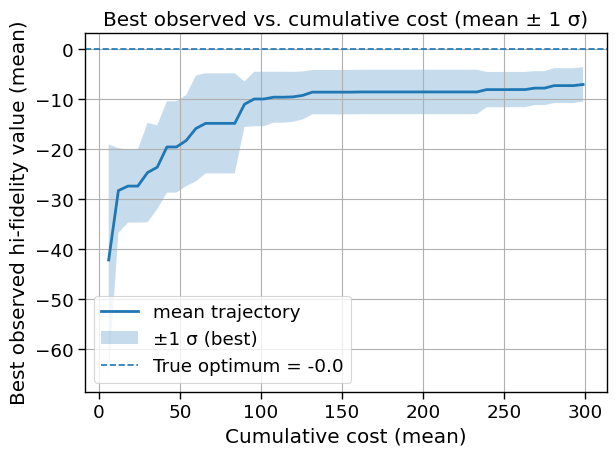

: 

In [ ]:
import matplotlib.pyplot as plt
from collections import OrderedDict

# ------------------------------------------------------------------
# 0)  Benchmarks and their custom settings
# ------------------------------------------------------------------
benchmarks = OrderedDict([
    # ("hartmann",   (AugmentedHartmann(negate=True), 60,  3.32237)),
    # ("branin",     (AugmentedBranin(negate=True), 50, -0.3978)),
    ("bukin",      (AugmentedBukin(negate=True), 50, -0.0)),
    # ("ackley",  (AugmentedAckley(dim=3, negate=True), 64,  0.0)),
    # ("rastrigin",  (AugmentedRastrigin(dim=3, negate=True), 50, -0.0)),
    # ("suzuki_mf", (SuzukiMFEmulator(num_samples=32, stochastic=True),60, None)),
])

SEEDS = [ 151, 33, 42, 88, 105, 67, ]  # 5 runs each

# ------------------------------------------------------------------
# 1)  Loop over benchmarks
# ------------------------------------------------------------------
for tag, (f, total_iters, opt_val) in benchmarks.items():
    print(f"\n=== Running {tag} (iters={total_iters}) ===")

    # 1a) independent runs
    run_dfs = [run_single(f=f, seed=s, total_iters=total_iters) for s in SEEDS]

    # # 1b) aggregate & save
    stats_df = aggregate_runs(run_dfs)
    out_csv  = f"mf_mes_runs_cont_{tag}.csv"
    stats_df.to_csv(out_csv, index=False)
    print(f"Saved aggregate stats → {out_csv}")

    # 1c) plots
    iters = stats_df["iteration"]

    plot_with_band(
        iters,
        stats_df["cumulative_cost_mean"],
        stats_df["cumulative_cost_std"],
        ylabel="Cumulative cost",
        title=f"{tag}: cumulative cost vs iteration (mean ± 1 σ)",
    )

    plot_with_band(
        iters,
        stats_df["best_hi_mean"],
        stats_df["best_hi_std"],
        ylabel="Best observed hi-fid value",
        title=f"{tag}: best observed vs iteration (mean ± 1 σ)",
    )

    plot_best_vs_cost(
        cost_mean=stats_df["cumulative_cost_mean"],
        cost_std=stats_df["cumulative_cost_std"],
        best_mean=stats_df["best_hi_mean"],
        best_std=stats_df["best_hi_std"],
        optimum_val=opt_val,          # show dashed line only if not None
    )
    plt.show()
# ------------------------------------------------------------------

